<a href="https://colab.research.google.com/github/rikharhm0208-coder/PROJECT_KOMPUTASI_KEUANGAN/blob/main/SIMULASI_TRINOMIAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

/tmp/ipykernel_9711/2238633429.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2025-03-12", end="2026-03-12")
[*********************100%***********************]  1 of 1 completed


Volatility: 0.2876487679999588


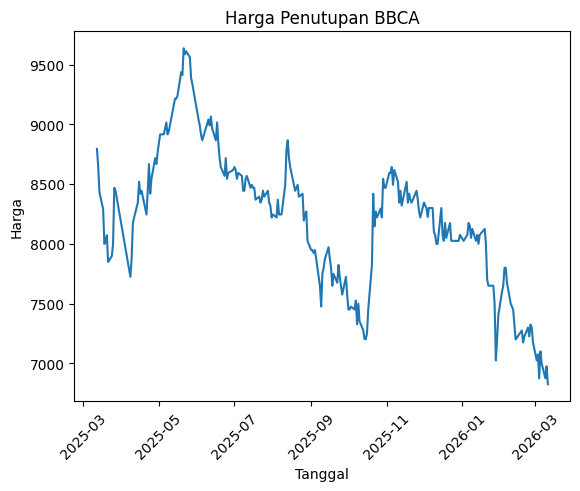

In [ ]:
# ==============================
# Ambil Data BBCA
# ==============================

ticker = "BBCA.JK"

data = yf.download(ticker, start="2025-03-12", end="2026-03-12")

# Jika kolom berbentuk MultiIndex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Reset index supaya Date jadi kolom biasa
data = data.reset_index()

# Harga penutupan
prices = data['Close']

# ==============================
# Log Return
# ==============================

log_return = np.log(prices / prices.shift(1)).dropna()

# Volatility tahunan
volatility = log_return.std() * np.sqrt(252)

print("Volatility:", volatility)

# ==============================
# Plot Harga BBCA
# ==============================

plt.figure()
plt.plot(data['Date'], prices)
plt.title("Harga Penutupan BBCA")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ==============================
# PARAMETER SIMULASI
# ==============================

T = 1          # horizon waktu (1 tahun)
L = 252        # jumlah langkah waktu (hari trading)
dt = T / L     # panjang interval waktu
S0 = prices.iloc[-1].item() # Harga awal simulasi

# ==============================
# Hitung Variansi log return
# ==============================
var_log = log_return.var()

# Estimasi sigma sesuai formula
sigma = (1/np.sqrt(dt)) * np.sqrt(var_log)

# ==============================
# Hitung mean log return
# ==============================
mean_log = log_return.mean()

# Estimasi mu sesuai formula
mu = (1/dt)*mean_log + 0.5*sigma**2

print("S0: ", S0)
print("mu: ", mu)
print("sigma: ", sigma)

S0:  6825.0
mu:  -0.23050107209861212
sigma:  0.28764876799995875


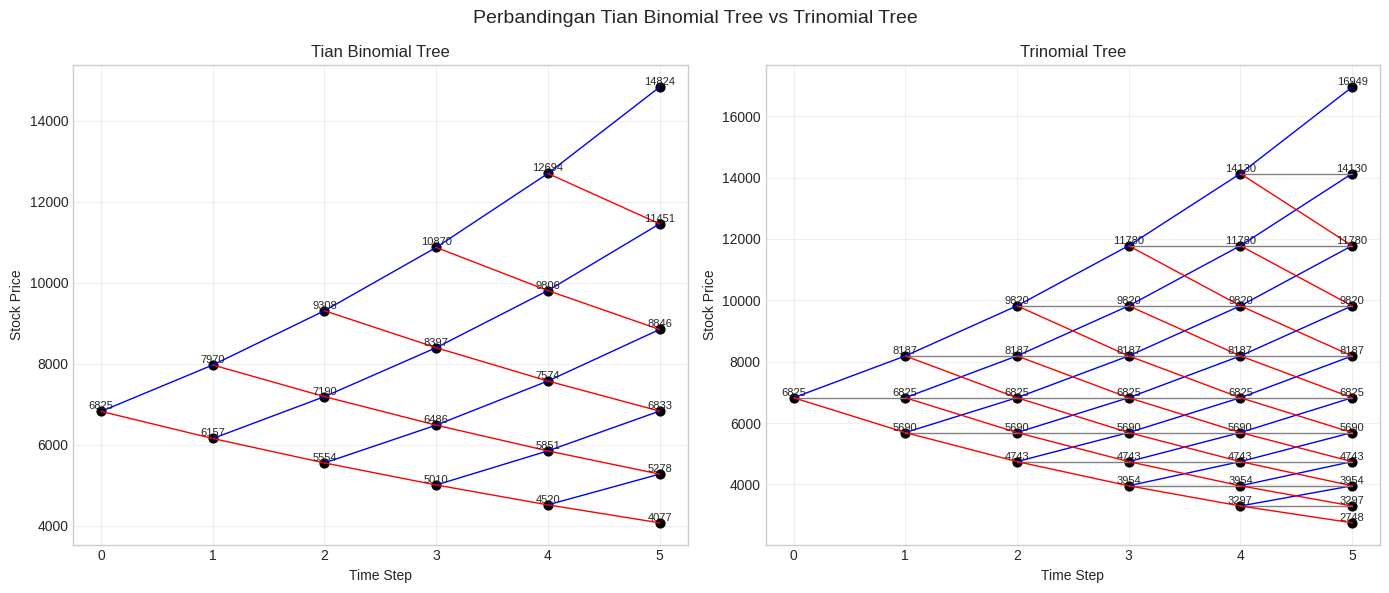

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# ==============================
# PARAMETER
# ==============================

N_plot = 5
r = 0.0475
dt = T / N_plot

# ==============================
# TIAN BINOMIAL PARAMETER
# ==============================

R = np.exp(r * dt)
V = np.exp(sigma**2 * dt)

u_tian = 0.5 * R * V * (V + 1 + np.sqrt(V**2 + 2*V - 3))
d_tian = 0.5 * R * V * (V + 1 - np.sqrt(V**2 + 2*V - 3))

# ==============================
# TRINOMIAL PARAMETER
# ==============================

u_tri = np.exp(sigma * np.sqrt(2*dt))
d_tri = np.exp(-sigma * np.sqrt(2*dt))
m_tri = 1

# ==============================
# BUILD TIAN TREE
# ==============================

def build_binomial_tree(S0, u, d, N):

    tree = []

    for i in range(N+1):

        level = []

        for j in range(i+1):

            price = S0*(u**j)*(d**(i-j))
            level.append(price)

        tree.append(level)

    return tree


# ==============================
# BUILD TRINOMIAL TREE
# ==============================

def build_trinomial_tree(S0, u, m, d, N):

    tree = []

    for i in range(N+1):

        level = []

        for j in range(-i, i+1):

            price = S0*(u**max(j,0))*(d**max(-j,0))
            level.append(price)

        tree.append(level)

    return tree


tree_tian = build_binomial_tree(S0, u_tian, d_tian, N_plot)
tree_tri = build_trinomial_tree(S0, u_tri, m_tri, d_tri, N_plot)

# ==============================
# PLOT BINOMIAL TREE
# ==============================

def plot_binomial_tree(ax, tree, u, d, title):

    for i in range(N_plot+1):

        for j in range(i+1):

            y = tree[i][j]

            ax.scatter(i, y, color="black", s=40)

            ax.text(i,
                    y,
                    f"{y:.0f}",
                    fontsize=8,
                    ha="center",
                    va="bottom")

            if i < N_plot:

                up = S0*(u**(j+1))*(d**(i-j))
                down = S0*(u**j)*(d**(i-j+1))

                ax.plot([i,i+1],[y,up],color="blue",linewidth=1)
                ax.plot([i,i+1],[y,down],color="red",linewidth=1)

    ax.set_title(title)
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Stock Price")
    ax.grid(alpha=0.3)


# ==============================
# PLOT TRINOMIAL TREE
# ==============================

def plot_trinomial_tree(ax, tree, u, m, d, title):

    for i in range(N_plot+1):

        nodes = tree[i]
        positions = range(-i, i+1)

        for k,j in enumerate(positions):

            y = nodes[k]

            ax.scatter(i, y, color="black", s=40)

            ax.text(i,
                    y,
                    f"{y:.0f}",
                    fontsize=8,
                    ha="center",
                    va="bottom")

            if i < N_plot:

                up = y*u
                mid = y*m
                down = y*d

                ax.plot([i,i+1],[y,up],color="blue",linewidth=1)
                ax.plot([i,i+1],[y,mid],color="grey",linewidth=1)
                ax.plot([i,i+1],[y,down],color="red",linewidth=1)

    ax.set_title(title)
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Stock Price")
    ax.grid(alpha=0.3)


# ==============================
# SUBPLOT
# ==============================

fig, ax = plt.subplots(1,2, figsize=(14,6))

plot_binomial_tree(ax[0], tree_tian, u_tian, d_tian, "Tian Binomial Tree")

plot_trinomial_tree(ax[1], tree_tri, u_tri, m_tri, d_tri, "Trinomial Tree")

plt.suptitle("Perbandingan Tian Binomial Tree vs Trinomial Tree", fontsize=14)

plt.tight_layout()
plt.show()

**HARGA OPSI**

In [ ]:
import numpy as np
from scipy.stats import norm

# =======================
# PARAMETER
# =======================

K = 7000
r = 0.0475
T = 1
N = 252


# =======================
# BLACK-SCHOLES MODEL
# =======================

def black_scholes(S0, K, r, sigma, T, option="call"):

    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option == "call":
        price = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

    return price


# =======================
# TIAN BINOMIAL MODEL
# =======================

def tian_option(S0, K, r, sigma, T, N, option="call", style="european"):

    dt = T/N

    R = np.exp(r*dt)
    V = np.exp(sigma**2 * dt)

    u = 0.5*R*V*(V+1 + np.sqrt(V**2 + 2*V -3))
    d = 0.5*R*V*(V+1 - np.sqrt(V**2 + 2*V -3))

    p = (R-d)/(u-d)

    stock = np.zeros((N+1,N+1))
    option_val = np.zeros((N+1,N+1))

    # Build stock tree
    for i in range(N+1):
        for j in range(i+1):
            stock[j,i] = S0*(u**(i-j))*(d**j)

    # Terminal payoff
    for j in range(N+1):

        if option == "call":
            option_val[j,N] = max(stock[j,N]-K,0)
        else:
            option_val[j,N] = max(K-stock[j,N],0)

    # Backward induction
    for i in range(N-1,-1,-1):
        for j in range(i+1):

            hold = np.exp(-r*dt)*(p*option_val[j,i+1] +
                                  (1-p)*option_val[j+1,i+1])

            if style == "american":

                if option == "call":
                    exercise = max(stock[j,i]-K,0)
                else:
                    exercise = max(K-stock[j,i],0)

                option_val[j,i] = max(hold,exercise)

            else:
                option_val[j,i] = hold

    return option_val[0,0]


# =======================
# TRINOMIAL MODEL
# =======================

def trinomial_option(S0, K, r, T, sigma, N, option="call", style="european"):

    dt = T/N
    disc = np.exp(-r*dt)

    u = np.exp(sigma*np.sqrt(2*dt))
    d = 1/u
    m = 1

    pu = ((np.exp(r*dt/2)-np.exp(-sigma*np.sqrt(dt/2))) /
          (np.exp(sigma*np.sqrt(dt/2))-np.exp(-sigma*np.sqrt(dt/2))))**2

    pd = ((np.exp(sigma*np.sqrt(dt/2))-np.exp(r*dt/2)) /
          (np.exp(sigma*np.sqrt(dt/2))-np.exp(-sigma*np.sqrt(dt/2))))**2

    pm = 1 - pu - pd

    stock = np.zeros((2*N+1, N+1))

    # Build stock tree
    for j in range(N+1):
        for i in range(2*j+1):

            up_moves = max(i-j,0)
            down_moves = max(j-i,0)

            stock[i,j] = S0*(u**up_moves)*(d**down_moves)

    option_val = np.zeros_like(stock)

    # Terminal payoff
    for i in range(2*N+1):

        if option == "call":
            option_val[i,N] = max(stock[i,N] - K,0)
        else:
            option_val[i,N] = max(K - stock[i,N],0)

    # Backward induction
    for j in range(N-1,-1,-1):

        for i in range(2*j+1):

            continuation = disc*(pu*option_val[i+2,j+1] +
                                 pm*option_val[i+1,j+1] +
                                 pd*option_val[i,j+1])

            if option == "call":
                intrinsic = max(stock[i,j]-K,0)
            else:
                intrinsic = max(K-stock[i,j],0)

            if style == "american":
                option_val[i,j] = max(intrinsic, continuation)
            else:
                option_val[i,j] = continuation

    return option_val[0,0]


# =======================
# BLACK-SCHOLES PRICE
# =======================

bs_call = black_scholes(S0, K, r, sigma, T, "call")
bs_put  = black_scholes(S0, K, r, sigma, T, "put")


# =======================
# TIAN BINOMIAL PRICE
# =======================

tian_call_e = tian_option(S0,K,r,sigma,T,N,"call","european")
tian_put_e  = tian_option(S0,K,r,sigma,T,N,"put","european")

tian_call_a = tian_option(S0,K,r,sigma,T,N,"call","american")
tian_put_a  = tian_option(S0,K,r,sigma,T,N,"put","american")


# =======================
# TRINOMIAL PRICE
# =======================

tri_call_e = trinomial_option(S0,K,r,T,sigma,N,"call","european")
tri_put_e  = trinomial_option(S0,K,r,T,sigma,N,"put","european")

tri_call_a = trinomial_option(S0,K,r,T,sigma,N,"call","american")
tri_put_a  = trinomial_option(S0,K,r,T,sigma,N,"put","american")


# =======================
# OUTPUT
# =======================

print("\nBLACK-SCHOLES")
print("Call :", bs_call)
print("Put  :", bs_put)

print("\nTIAN BINOMIAL MODEL")
print("European Call :", tian_call_e)
print("American Call :", tian_call_a)
print("European Put  :", tian_put_e)
print("American Put  :", tian_put_a)

print("\nTRINOMIAL MODEL")
print("European Call :", tri_call_e)
print("American Call :", tri_call_a)
print("European Put  :", tri_put_e)
print("American Put  :", tri_put_a)


BLACK-SCHOLES
Call : 849.0930215003586
Put  : 699.3663334287435

TIAN BINOMIAL MODEL
European Call : 848.8036239019668
American Call : 848.8036239019668
European Put  : 699.0769358302324
American Put  : 738.7418791390234

TRINOMIAL MODEL
European Call : 848.7322942581343
American Call : 848.7322942581343
European Put  : 699.0056061864198
American Put  : 738.6431889613391


In [ ]:
import pandas as pd
import numpy as np

results = pd.DataFrame({

    "Model":[
        "Black-Scholes",
        "Tian Binomial",
        "Trinomial"
    ],

    "European Call":[
        bs_call,
        tian_call_e,
        tri_call_e
    ],

     "European Put":[
        bs_put,
        tian_put_e,
        tri_put_e
    ],

    "American Call":[
        np.nan,
        tian_call_a,
        tri_call_a
    ],


    "American Put":[
        np.nan,
        tian_put_a,
        tri_put_a
    ]

})

print("\nOPTION PRICE COMPARISON")
print(results.round(4))


OPTION PRICE COMPARISON
           Model  European Call  European Put  American Call  American Put
0  Black-Scholes       849.0930      699.3663            NaN           NaN
1  Tian Binomial       848.8036      699.0769       848.8036      738.7419
2      Trinomial       848.7323      699.0056       848.7323      738.6432


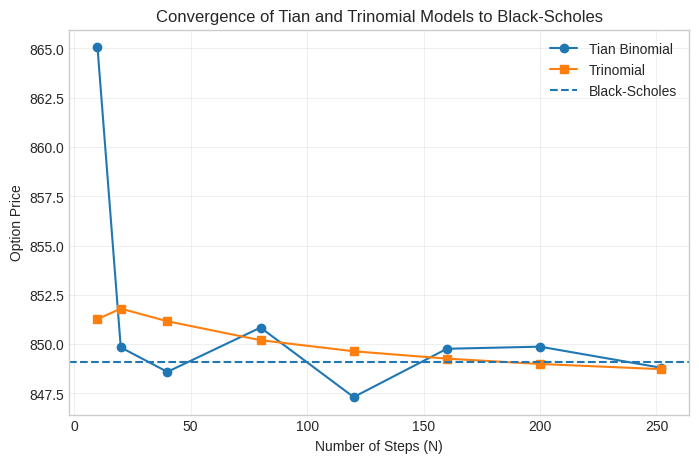

In [ ]:
import matplotlib.pyplot as plt

# ==============================
# RANGE STEP
# ==============================

steps = [10,20,40,80,120,160,200,252]

tian_prices = []
tri_prices = []

# ==============================
# HITUNG HARGA OPSI
# ==============================

for N in steps:

    tian_price = tian_option(S0,K,r,sigma,T,N,"call","european")
    tri_price = trinomial_option(S0,K,r,T,sigma,N,"call","european")

    tian_prices.append(tian_price)
    tri_prices.append(tri_price)

# ==============================
# BLACK-SCHOLES REFERENCE
# ==============================

bs_price = black_scholes(S0,K,r,sigma,T,"call")

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(8,5))

plt.plot(steps,
         tian_prices,
         marker='o',
         label="Tian Binomial")

plt.plot(steps,
         tri_prices,
         marker='s',
         label="Trinomial")

plt.axhline(bs_price,
            linestyle='--',
            label="Black-Scholes")

plt.xlabel("Number of Steps (N)")
plt.ylabel("Option Price")
plt.title("Convergence of Tian and Trinomial Models to Black-Scholes")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

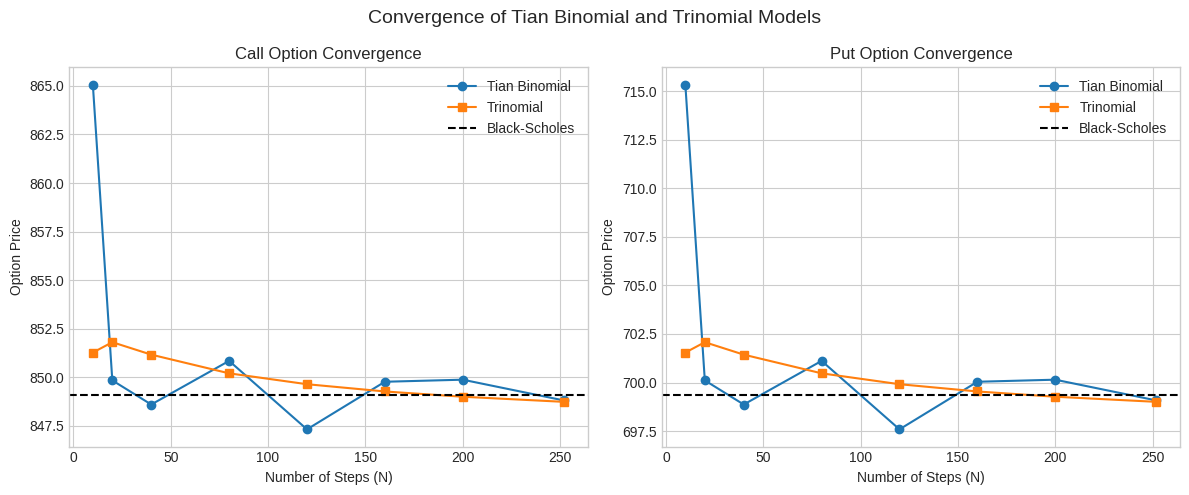

In [ ]:
import matplotlib.pyplot as plt

# ==========================
# RANGE STEP
# ==========================

steps = [10,20,40,80,120,160,200,252]

tian_call = []
tri_call = []

tian_put = []
tri_put = []

# ==========================
# HITUNG HARGA OPSI
# ==========================

for N in steps:

    # CALL
    tian_call.append(tian_option(S0,K,r,sigma,T,N,"call","european"))
    tri_call.append(trinomial_option(S0,K,r,T,sigma,N,"call","european"))

    # PUT
    tian_put.append(tian_option(S0,K,r,sigma,T,N,"put","european"))
    tri_put.append(trinomial_option(S0,K,r,T,sigma,N,"put","european"))

# ==========================
# BLACK-SCHOLES
# ==========================

bs_call = black_scholes(S0,K,r,sigma,T,"call")
bs_put = black_scholes(S0,K,r,sigma,T,"put")

# ==========================
# PLOT
# ==========================

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(1,2, figsize=(12,5))

# --------------------------------
# CALL CONVERGENCE
# --------------------------------

ax[0].plot(steps, tian_call, marker='o', label="Tian Binomial")
ax[0].plot(steps, tri_call, marker='s', label="Trinomial")

ax[0].axhline(bs_call,
              linestyle='--',
              color='black',
              label="Black-Scholes")

ax[0].set_title("Call Option Convergence")
ax[0].set_xlabel("Number of Steps (N)")
ax[0].set_ylabel("Option Price")
ax[0].legend()

# --------------------------------
# PUT CONVERGENCE
# --------------------------------

ax[1].plot(steps, tian_put, marker='o', label="Tian Binomial")
ax[1].plot(steps, tri_put, marker='s', label="Trinomial")

ax[1].axhline(bs_put,
              linestyle='--',
              color='black',
              label="Black-Scholes")

ax[1].set_title("Put Option Convergence")
ax[1].set_xlabel("Number of Steps (N)")
ax[1].set_ylabel("Option Price")
ax[1].legend()

plt.suptitle("Convergence of Tian Binomial and Trinomial Models", fontsize=14)

plt.tight_layout()
plt.show()